# Notebook 05: Acurácia Posicional e Cálculo do GCI Composto

Fecha o loop de validação extrínseca: compara cada ponto CNEFE com seu par BHMap, calcula as métricas de acurácia posicional (RMSE, CE90, MAE) e monta o GCI composto em duas versões, `GCI_original` com PCI arbitrário (Davis & Fonseca, 2007) e `GCI_empirico` com PCI = 1/CDI.

A validação formal do GCI_empirico, Spearman ρ com erro posicional, validade discriminante por PCA e ablation study, fica no Notebook 07.

**Hipóteses respondidas neste notebook:**
- **H1** (Apartamentos têm GCI menor): boxplot de GCI por tipologia com Mann-Whitney U
- **H2** (NV_GEO_COORD correlaciona com erro): violin plot GCI por NV_GEO_COORD com Kruskal-Wallis
- **Posicionamento na literatura**: RMSE do CNEFE vs. Google Maps em BH (Davis & Alencar, 2011)


In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, os, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config
from src.metrics import (
    calculate_lci, calculate_pci, calculate_completude,
    calculate_gci, calculate_rmse, calculate_ce90
)

# ── Carregar matching e métricas de coordenada ────────────────────────────────
gdf_matched = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_matched.parquet')
coord_m = pd.read_parquet(config.PROCESSED_DIR / 'cnefe_coordinate_metrics.parquet')
gdf_matched = gdf_matched.join(
    coord_m[['cdi', 'pci_empirico', 'ccr', 'drs', 'csi']], how='left'
)

# ── Calcular LCI, PCI e GCI ──────────────────────────────────────────────────
gdf_matched['LCI']           = calculate_lci(gdf_matched['NV_GEO_COORD'])
gdf_matched['PCI_arbitrario']= calculate_pci(gdf_matched)
gdf_matched['PCI']           = gdf_matched['PCI_arbitrario']
gdf_matched['COMPLETUDE']    = calculate_completude(gdf_matched)
gdf_matched['GCI_original']  = calculate_gci(
    gdf_matched['LCI'], gdf_matched['MCI'], gdf_matched['PCI_arbitrario']
)
gdf_matched['GCI_empirico']  = calculate_gci(
    gdf_matched['LCI'], gdf_matched['MCI'], gdf_matched['pci_empirico']
)
gdf_matched['GCI'] = gdf_matched['GCI_empirico']

# ── Salvar master_metrics_base (entrada do enrich_master_metrics.py) ─────────
out_base = config.PROCESSED_DIR / 'cnefe_master_metrics_base.parquet'
gdf_matched.to_parquet(out_base)
print(f"Salvo: cnefe_master_metrics_base.parquet  ({len(gdf_matched):,} × {len(gdf_matched.columns)} colunas)")
print(f"  LCI médio:          {gdf_matched['LCI'].mean():.3f}")
print(f"  GCI_original médio: {gdf_matched['GCI_original'].mean():.3f}")
print(f"  GCI_empirico médio: {gdf_matched['GCI_empirico'].mean():.3f}")


def kruskal_wallis_test(df, metric_col, segment_col):
    groups = [g[metric_col].dropna().values for _, g in df.groupby(segment_col, observed=True)]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        return {'H': np.nan, 'p_value': np.nan, 'significativo': False, 'n_groups': len(groups)}
    h_stat, p_val = stats.kruskal(*groups)
    return {'H': h_stat, 'p_value': p_val, 'significativo': p_val < 0.05, 'n_groups': len(groups)}


def mann_whitney_test(df, metric_col, segment_col, group_a, group_b):
    seg = df[segment_col] if isinstance(segment_col, str) else segment_col
    a = df.loc[seg == group_a, metric_col].dropna()
    b = df.loc[seg == group_b, metric_col].dropna()
    if len(a) == 0 or len(b) == 0:
        return {'U': np.nan, 'p_value': np.nan, 'significativo': False,
                'effect_size_r': np.nan, 'mean_a': np.nan, 'mean_b': np.nan}
    u_stat, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')
    n1, n2 = len(a), len(b)
    r = 1 - (2 * u_stat) / (n1 * n2)
    return {'U': u_stat, 'p_value': p_val, 'significativo': p_val < 0.05,
            'effect_size_r': r, 'mean_a': a.mean(), 'mean_b': b.mean()}

Salvo: cnefe_master_metrics_base.parquet  (1,172,902 × 38 colunas)
  LCI médio:          0.965
  GCI_original médio: 0.637
  GCI_empirico médio: 0.482


## 2. Acurácia Posicional Física (RMSE e CE90)

RMSE penaliza grandes desvios quadraticamente; CE90 é o raio que contém 90% dos erros, mais robusto a outliers e padrão em cartografia. O erro posicional aqui não mede qualidade do geocodificador (o CNEFE não interpola logradouros), mas sim a dispersão intrínseca das coordenadas GPS de campo em relação ao cadastro BHMap.

In [2]:
distancias = gdf_matched['match_distance'].dropna()

rmse = calculate_rmse(distancias)
ce90 = calculate_ce90(distancias)
mae = np.mean(np.abs(distancias))
mediana = np.median(distancias)

print("=" * 50)
print("ACURÁCIA POSICIONAL GLOBAL")
print("=" * 50)
print(f"  RMSE:    {rmse:.2f} metros")
print(f"  CE90:    {ce90:.2f} metros")
print(f"  MAE:     {mae:.2f} metros")
print(f"  Mediana: {mediana:.2f} metros")
print(f"  Max:     {distancias.max():.2f} metros")
print(f"\n  < 10m:   {(distancias < 10).mean()*100:.1f}%")
print(f"  < 25m:   {(distancias < 25).mean()*100:.1f}%")
print(f"  < 50m:   {(distancias < 50).mean()*100:.1f}%")


ACURÁCIA POSICIONAL GLOBAL
  RMSE:    15.55 metros
  CE90:    21.02 metros
  MAE:     10.14 metros
  Mediana: 6.47 metros
  Max:     99.97 metros

  < 10m:   72.2%
  < 25m:   92.3%
  < 50m:   97.8%


RMSE = 15,55m, CE90 = 21,02m e MAE = 10,14m enquadram o CNEFE na classe cartográfica 1:50.000 (CE90 ≤ 25m pelo PEC/IBGE). Para geocodificação urbana (epidemiologia, acessibilidade, criminalidade), esse nível é adequado. O ponto importante é que 72,2% dos registros estão dentro de 10m do par BHMap; a mediana de 6,47m mostra que o caso típico é de alta precisão e os outliers que puxam o RMSE para cima são a minoria.

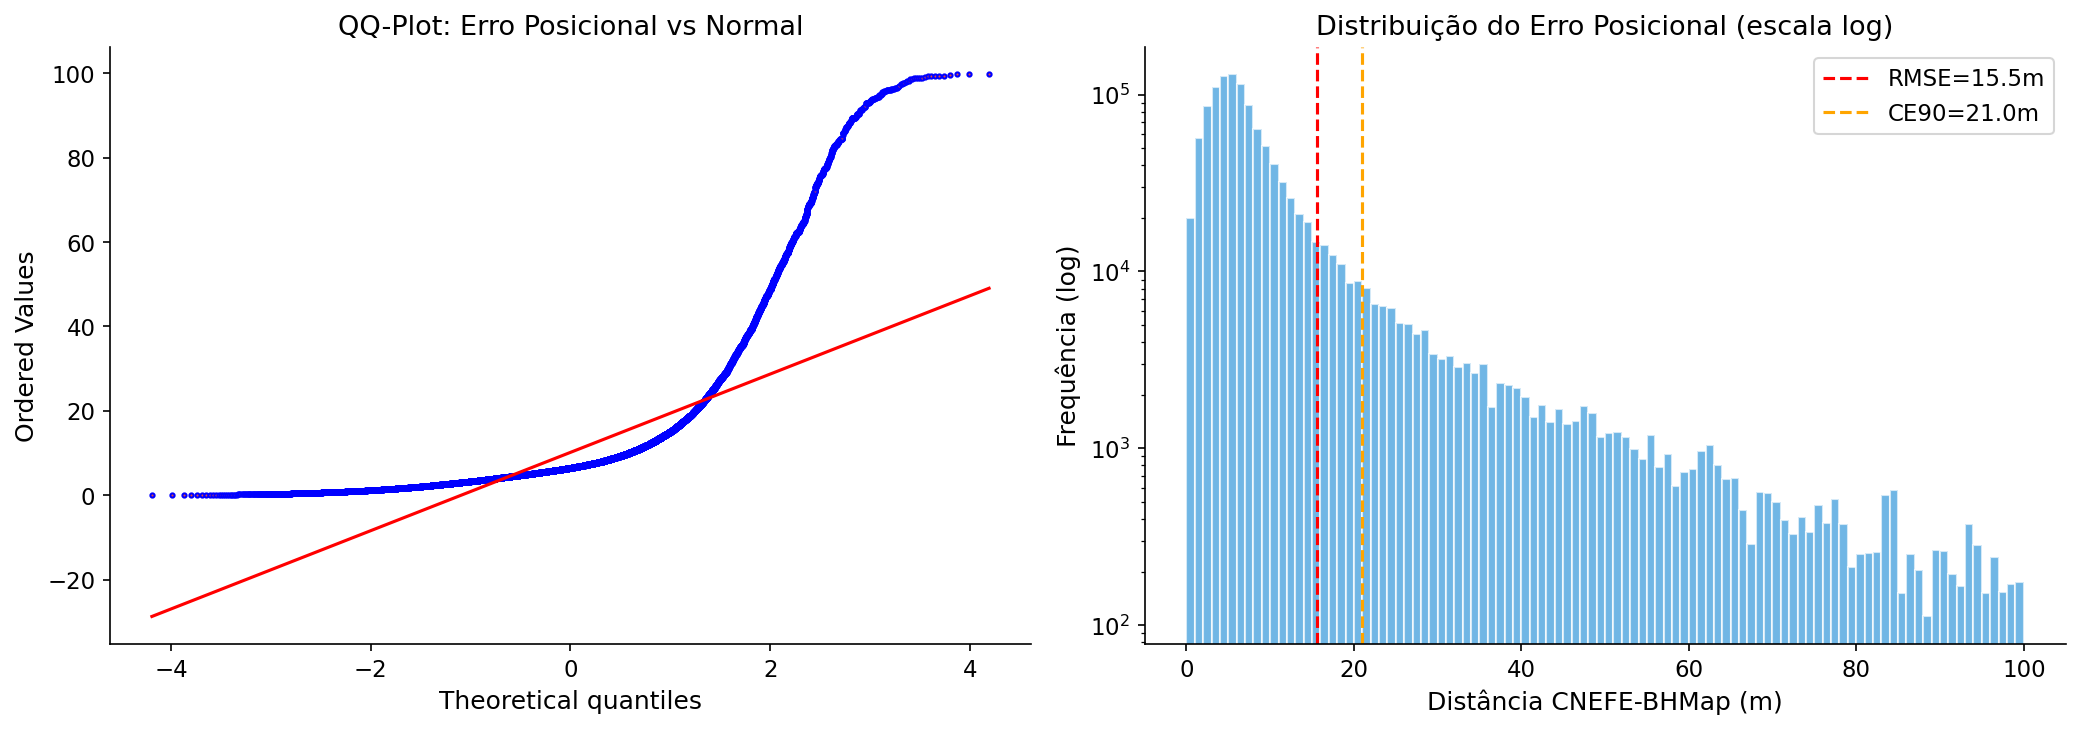

In [3]:
# QQ-Plot: Teste de normalidade do erro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QQ-Plot
stats.probplot(distancias.sample(min(50000, len(distancias)), random_state=42),
               dist="norm", plot=axes[0])
axes[0].set_title('QQ-Plot: Erro Posicional vs Normal', fontsize=13)
axes[0].get_lines()[0].set_markerfacecolor('#e74c3c')
axes[0].get_lines()[0].set_markersize(2)

# Histogram (log scale)
axes[1].hist(distancias, bins=100, color='#3498db', alpha=0.7, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribuição do Erro Posicional (escala log)', fontsize=13)
axes[1].set_xlabel('Distância CNEFE-BHMap (m)')
axes[1].set_ylabel('Frequência (log)')
axes[1].axvline(x=rmse, color='red', linestyle='--', label=f'RMSE={rmse:.1f}m')
axes[1].axvline(x=ce90, color='orange', linestyle='--', label=f'CE90={ce90:.1f}m')
axes[1].legend()

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb05_qqplot_histograma.png', dpi=200, bbox_inches='tight')
plt.show()


O QQ-Plot confirma que o erro posicional não segue distribuição normal: os pontos se afastam sistematicamente da diagonal nas extremidades, com cauda direita pesada. A distribuição é aproximadamente log-normal, padrão documentado na literatura de geocodificação urbana (Zandbergen, 2008). Reportar apenas RMSE seria enganoso; o CE90 de 21,02m é a métrica primária da dissertação, mais robusto a outliers e diretamente comparável com outros estudos.

### Mapa de Deslocamento CNEFE para BHMap

Cada linha liga a coordenada do CNEFE ao seu par correspondente no BHMap, no estilo da visualização de Davis & Alencar (2011). O comprimento e a orientação das linhas mostram a magnitude e a direção do erro posicional: vetores curtos e sem orientação preferencial indicam ruído de medição, enquanto vetores longos e alinhados indicariam deslocamento sistemático.

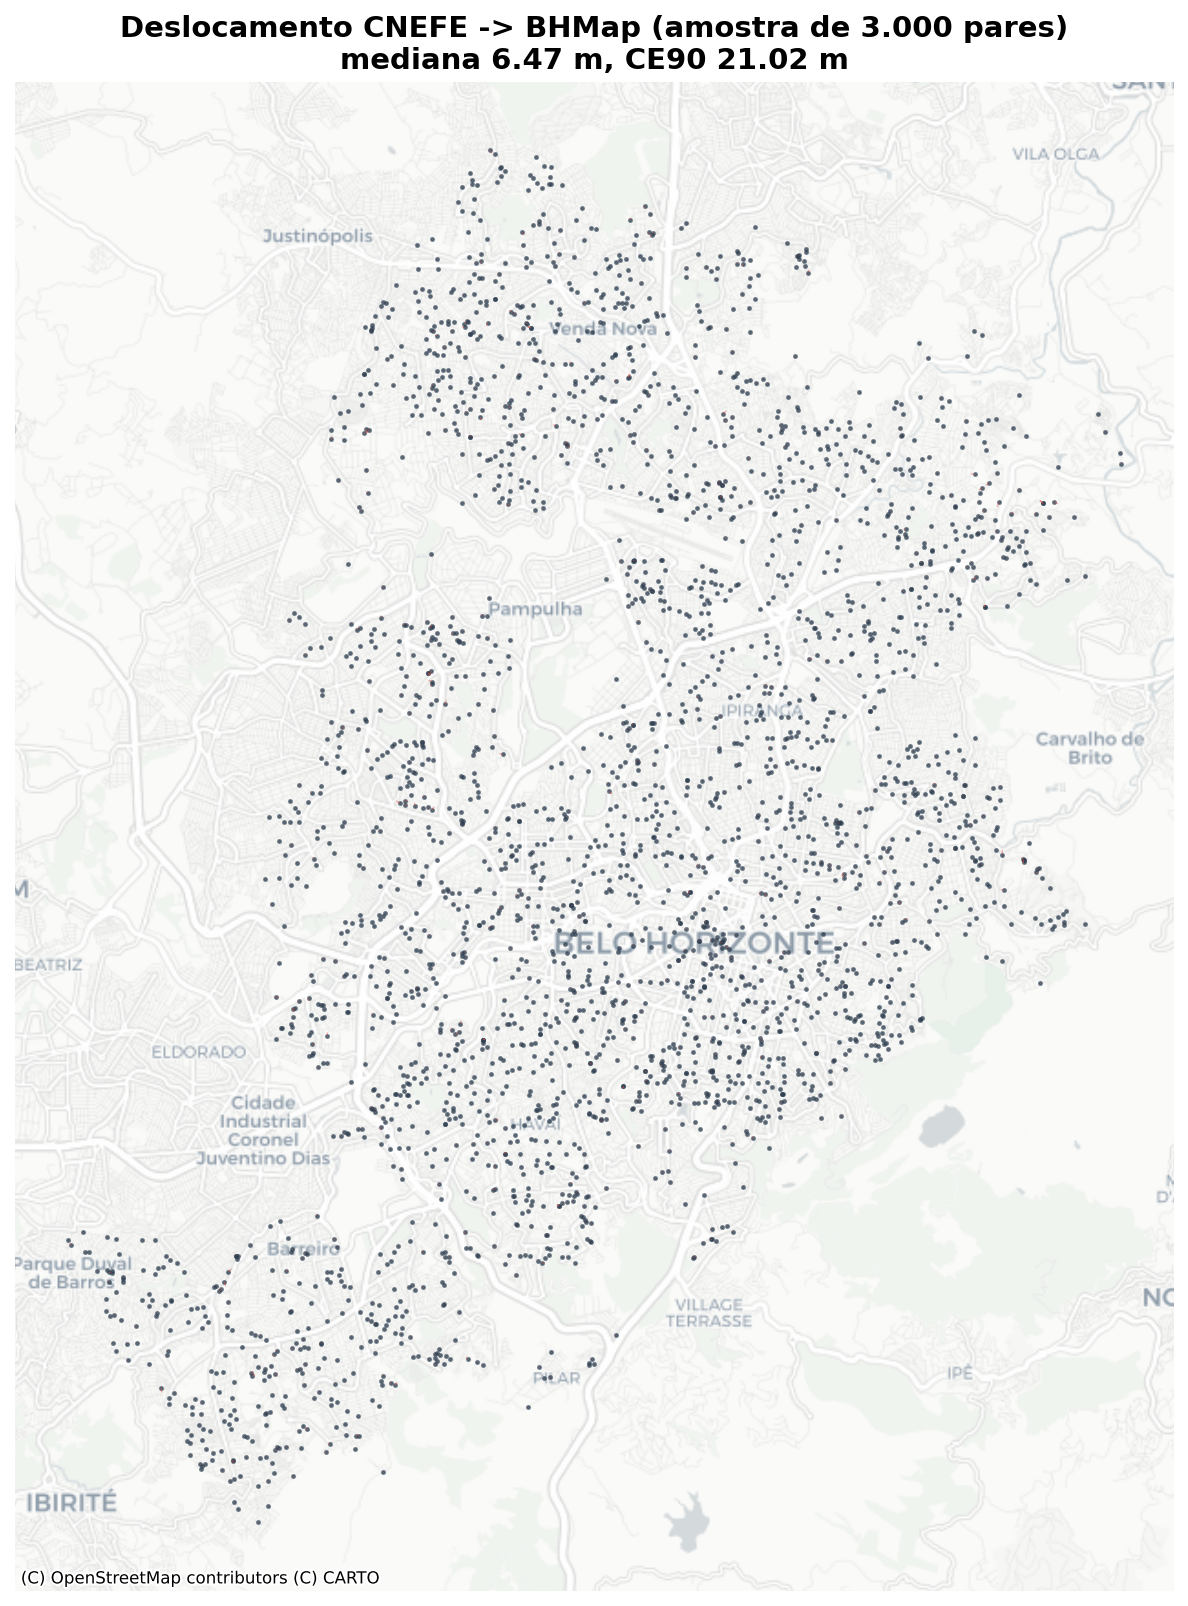

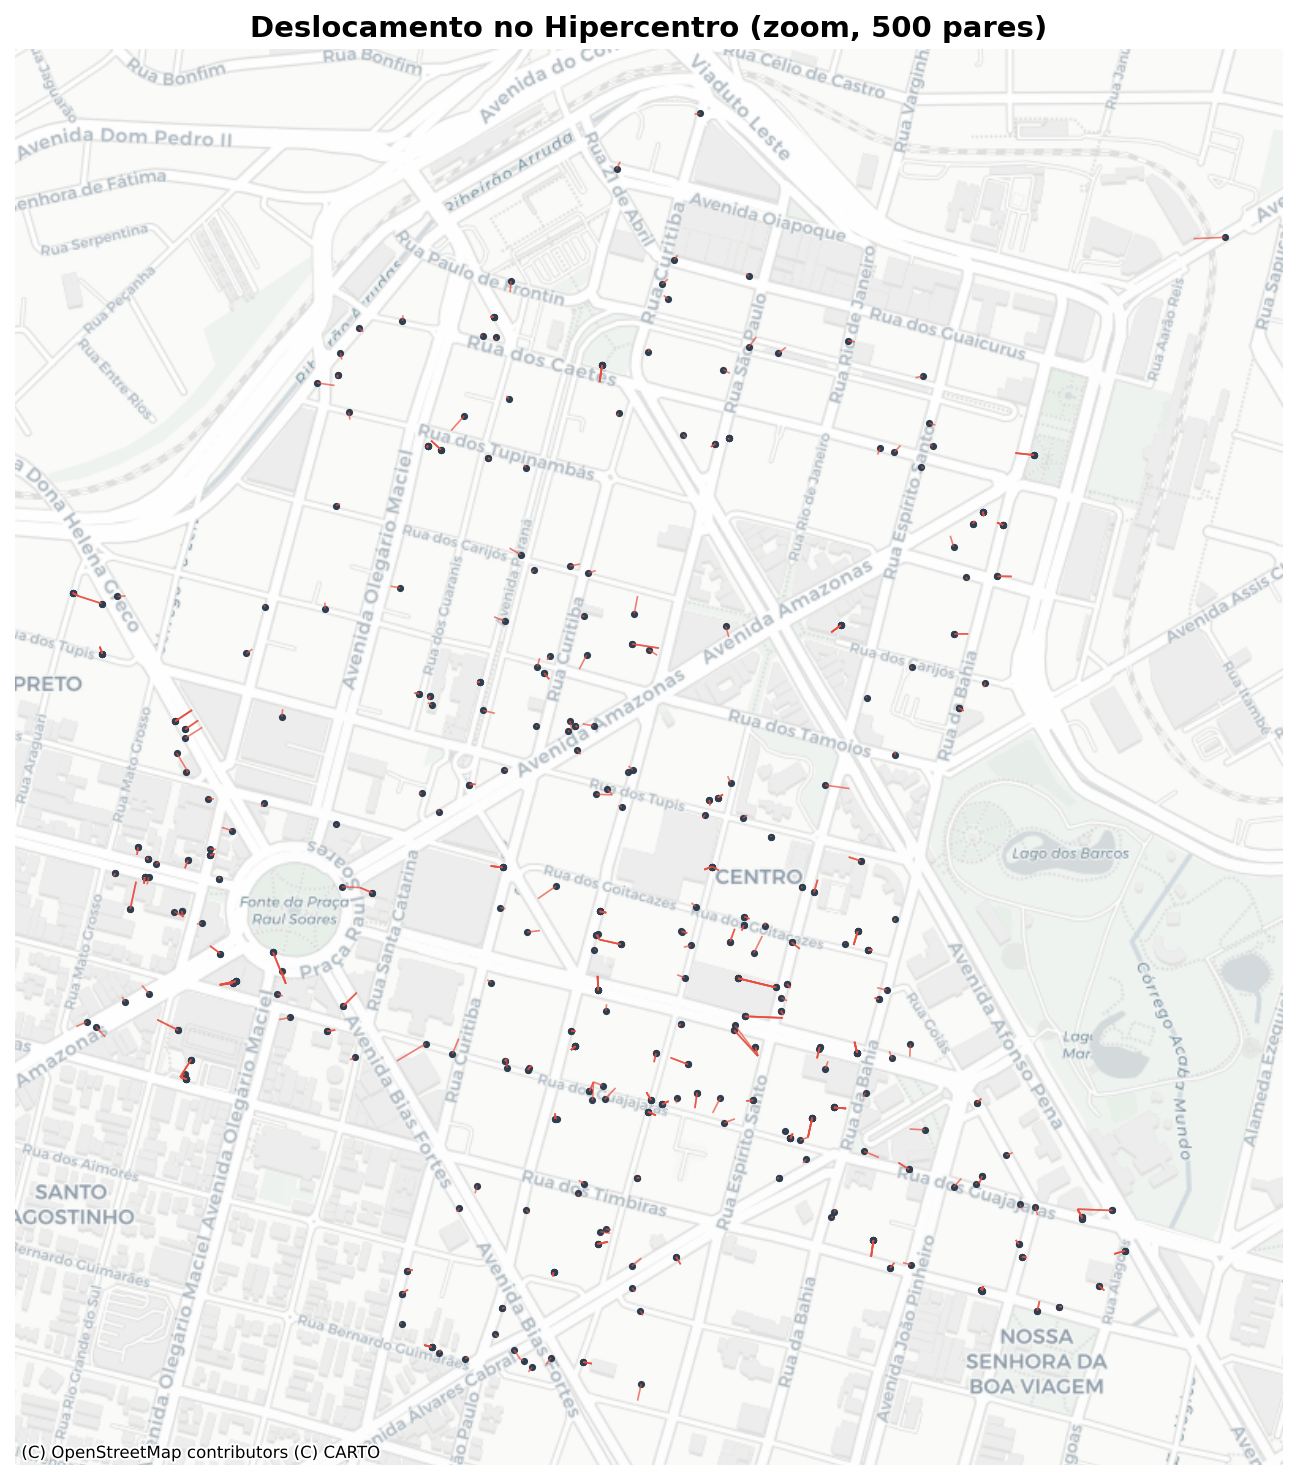

Mapa de deslocamento: 3,000 pares amostrados | deslocamento mediano 6.58 m


In [4]:
from shapely.geometry import LineString

# Vetores de deslocamento CNEFE -> BHMap (amostra)
_smp = gdf_matched.dropna(subset=['bhmap_geom', 'match_distance']).sample(
    min(3000, len(gdf_matched)), random_state=42)
_lines = gpd.GeoSeries(
    [LineString([a, b]) for a, b in zip(_smp.geometry, _smp['bhmap_geom'])],
    crs=gdf_matched.crs).to_crs(epsg=3857)
_pts = _smp.set_geometry('geometry').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 11))
_lines.plot(ax=ax, linewidth=0.5, color='#e74c3c', alpha=0.5)
_pts.plot(ax=ax, markersize=2, color='#2c3e50', alpha=0.6)
try:
    import contextily as ctx
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
except Exception as e:
    print(f'Basemap indisponivel ({e})')
ax.set_title('Deslocamento CNEFE -> BHMap (amostra de 3.000 pares)\n'
             f'mediana {mediana:.2f} m, CE90 {ce90:.2f} m', fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb05_mapa_deslocamento.png', dpi=200, bbox_inches='tight')
plt.show()

# Zoom no Hipercentro, onde os vetores sao maiores
if 'NOME_REGIO' in gdf_matched.columns:
    _hc = gdf_matched[gdf_matched['NOME_REGIO'] == 'HIPERCENTRO'].dropna(subset=['bhmap_geom'])
    if len(_hc) > 0:
        _hc = _hc.sample(min(500, len(_hc)), random_state=42)
        _hc_lines = gpd.GeoSeries(
            [LineString([a, b]) for a, b in zip(_hc.geometry, _hc['bhmap_geom'])],
            crs=gdf_matched.crs).to_crs(epsg=3857)
        fig, ax = plt.subplots(figsize=(10, 10))
        _hc_lines.plot(ax=ax, linewidth=0.8, color='#e74c3c', alpha=0.7)
        _hc.set_geometry('geometry').to_crs(epsg=3857).plot(ax=ax, markersize=6, color='#2c3e50')
        try:
            import contextily as ctx
            ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
        except Exception:
            pass
        ax.set_title('Deslocamento no Hipercentro (zoom, 500 pares)', fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(config.FIG_DIR / 'nb05_deslocamento_hipercentro.png', dpi=200, bbox_inches='tight')
        plt.show()

print(f"Mapa de deslocamento: {len(_smp):,} pares amostrados | "
      f"deslocamento mediano {_smp['match_distance'].median():.2f} m")

O deslocamento é predominantemente curto e sem direção dominante, coerente com ruído de medição GPS e não com um viés sistemático de projeção ou datum. Os vetores mais longos concentram-se no Hipercentro, onde a verticalização faz muitas unidades compartilharem um ponto que pode ficar a alguns metros da fachada cadastrada no BHMap. A mediana de 6,47 m e o CE90 de 21,02 m resumem essa distribuição.

## 3. PCI: Positional Certainty Indicator e GCI Composto

Davis & Fonseca (2007) argumentam que um ponto geocodificado num edifício de 80 apartamentos tem incerteza posicional intrínseca: a coordenada (x,y) é a mesma para todas as unidades. O PCI original penaliza isso com uma regra binária (Casa=1,0; Apartamento=0,5). Aqui calculamos também o PCI_empirico = 1/CDI, que calibra essa penalização automaticamente a partir da densidade de coordenadas compartilhadas, sem precisar de regra arbitrária.

In [5]:
# PCI: Casa(101)=1.0, Apartamento(103)=0.5, demais=1.0  (Davis & Fonseca, 2007)
print("--- PCI ---")
print(gdf_matched['PCI'].value_counts().sort_index(ascending=False))
print(f"\nEndereços verticalizados (PCI=0.5): "
      f"{(gdf_matched['PCI']==0.5).sum():,} "
      f"({(gdf_matched['PCI']==0.5).mean()*100:.1f}%)")

print(f"\n--- GCI_original (LCI × MCI × PCI_arbitrario) ---")
gci = gdf_matched['GCI_original'].dropna()
print(gci.describe().round(3))
print(f"\nGCI_original < 0.5: {(gci < 0.5).mean()*100:.1f}%")

print(f"\n--- GCI_empirico (LCI × MCI × 1/CDI) ---")
gci_emp = gdf_matched['GCI_empirico'].dropna()
print(gci_emp.describe().round(3))
print(f"\nGCI_empirico < 0.5: {(gci_emp < 0.5).mean()*100:.1f}%")

--- PCI ---
PCI
1.0    720900
0.5    452002
Name: count, dtype: int64

Endereços verticalizados (PCI=0.5): 452,002 (38.5%)

--- GCI_original (LCI × MCI × PCI_arbitrario) ---
count    1172902.000
mean           0.637
std            0.241
min            0.029
25%            0.400
50%            0.750
75%            0.861
max            0.969
Name: GCI_original, dtype: float64

GCI_original < 0.5: 39.8%

--- GCI_empirico (LCI × MCI × 1/CDI) ---
count    1172902.000
mean           0.482
std            0.346
min            0.001
25%            0.084
50%            0.577
75%            0.829
max            0.966
Name: GCI_empirico, dtype: float64

GCI_empirico < 0.5: 47.5%


Com 38,5% dos registros sendo apartamentos, o GCI composto apresenta distribuição bimodal: um pico acima de 0,8 (casas com CDI=1) e outro abaixo de 0,5 (apartamentos com CDI alto). O GCI_original médio global é 0,637, enquanto o GCI_empírico médio é 0,482. A diferença reflete a penalização mais severa do PCI_empírico nos edifícios de alta verticalização.

### 3.x ECDF das Métricas do GCI

A ECDF permite afirmações exatas como "X% dos endereços têm GCI_empírico ≥ 0,7" sem depender de escolha de bin. LCI, MCI, PCI e os dois GCIs aparecem na mesma escala [0, 1], revelando qual componente é o gargalo do índice.

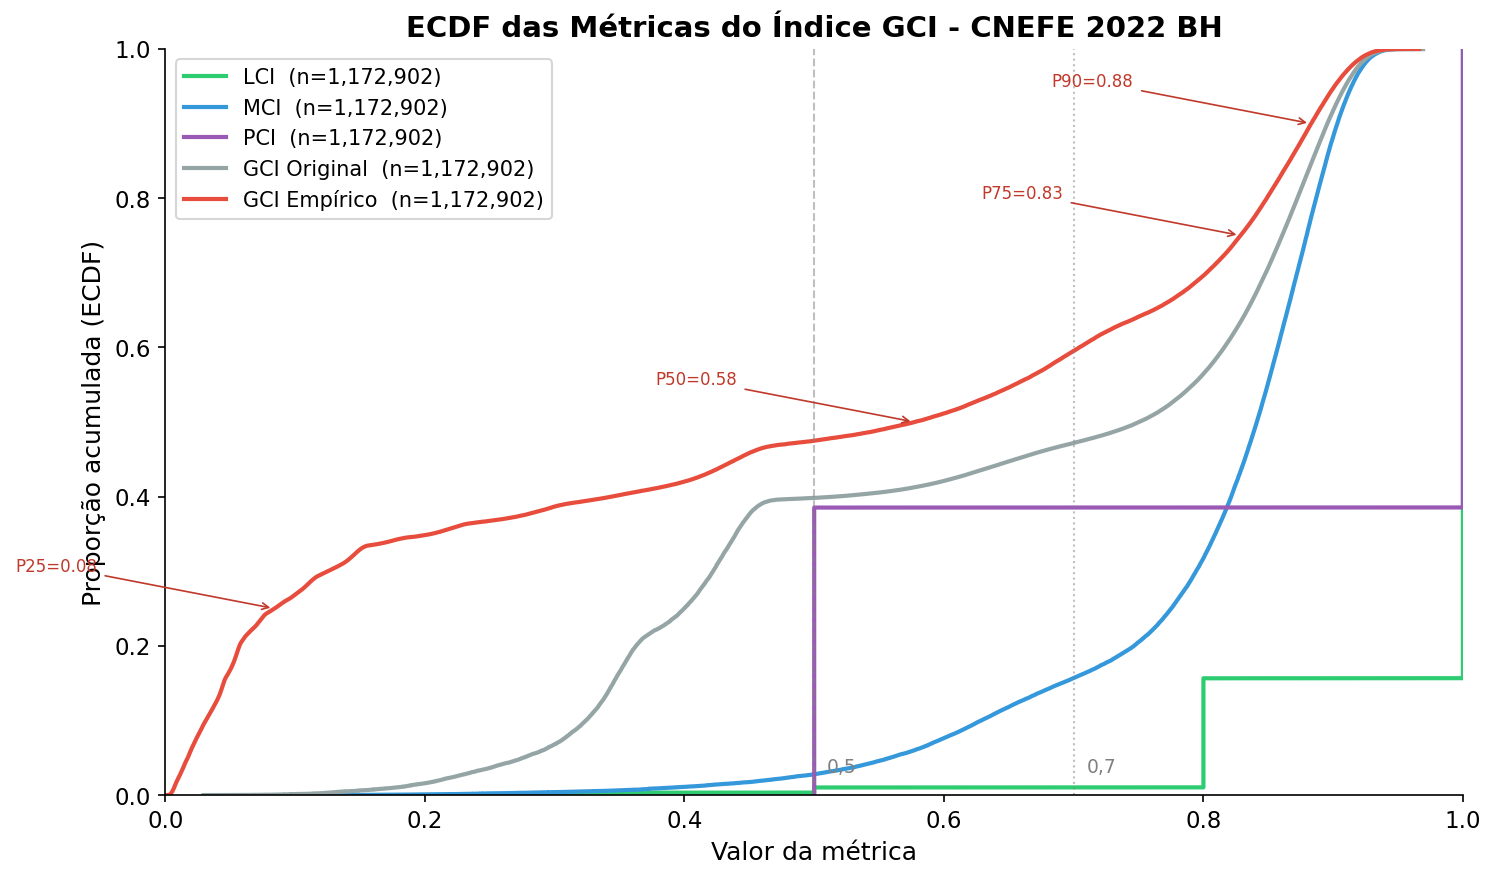

Metrica,N,pct_lt_05,pct_ge_07,pct_ge_09,P10,P25,P50,P75,P90,P95
LCI,"1,172,902",0.3%,99.0%,84.3%,0.800,1.000,1.000,1.000,1.000,1.000
MCI,"1,172,902",2.8%,84.3%,11.7%,0.629,0.775,0.841,0.880,0.903,0.914
PCI,"1,172,902",0.0%,61.5%,61.5%,0.500,0.500,1.000,1.000,1.000,1.000
GCI Original,"1,172,902",39.8%,52.8%,8.2%,0.324,0.400,0.750,0.861,0.896,0.909
GCI Empírico,"1,172,902",47.5%,40.5%,5.3%,0.031,0.084,0.577,0.829,0.883,0.901


In [6]:
# ECDF das métricas do índice GCI: LCI, MCI, PCI, GCI_original, GCI_empirico

ECDF_COLS = {
    'LCI':          ('#2ecc71', 'LCI'),
    'MCI':          ('#3498db', 'MCI'),
    'PCI':          ('#9b59b6', 'PCI'),
    'GCI_original': ('#95a5a6', 'GCI Original'),
    'GCI_empirico': ('#e74c3c', 'GCI Empírico'),
}

fig, ax = plt.subplots(figsize=(10, 6))
for col, (color, label) in ECDF_COLS.items():
    if col not in gdf_matched.columns:
        continue
    vals = gdf_matched[col].dropna().sort_values().values
    ecdf_y = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, ecdf_y, color=color, linewidth=2, label=f'{label}  (n={len(vals):,})')

for xref, ls, lbl in [(0.5, '--', '0,5'), (0.7, ':', '0,7')]:
    ax.axvline(xref, color='gray', linestyle=ls, alpha=0.5, linewidth=1)
    ax.text(xref + 0.01, 0.03, lbl, color='gray', fontsize=9)

# Anotar percentis P25/P50/P75/P90 do GCI_empirico
if 'GCI_empirico' in gdf_matched.columns:
    for pct in [0.25, 0.50, 0.75, 0.90]:
        val = gdf_matched['GCI_empirico'].quantile(pct)
        ax.annotate(f'P{int(pct*100)}={val:.2f}',
                    xy=(val, pct), xytext=(val - 0.20, pct + 0.05),
                    fontsize=8, color='#c0392b',
                    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=0.8))

ax.set_xlabel('Valor da métrica')
ax.set_ylabel('Proporção acumulada (ECDF)')
ax.set_title('ECDF das Métricas do Índice GCI - CNEFE 2022 BH', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb05_ecdf_metricas_gci.png', dpi=200, bbox_inches='tight')
plt.show()

# Tabela de percentis
pcts = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
rows = []
for col, (_, label) in ECDF_COLS.items():
    if col not in gdf_matched.columns:
        continue
    v = gdf_matched[col].dropna()
    row = {'Metrica': label, 'N': f'{len(v):,}',
           'pct_lt_05': f'{(v < 0.5).mean()*100:.1f}%',
           'pct_ge_07': f'{(v >= 0.7).mean()*100:.1f}%',
           'pct_ge_09': f'{(v >= 0.9).mean()*100:.1f}%'}
    for p in pcts:
        row[f'P{int(p*100)}'] = f'{v.quantile(p):.3f}'
    rows.append(row)
df_pct = pd.DataFrame(rows)
display(df_pct.style.set_caption('Percentis das metricas GCI').hide(axis='index'))
df_pct.to_csv(config.TAB_DIR / 'nb05_ecdf_percentis_gci.csv', index=False)


GCI_empírico tem P50 = 0,577 e P25 = 0,084; o GCI_original tem P50 = 0,750. A diferença entre as curvas é o efeito do CDI: o método empírico penaliza mais duramente os apartamentos em edifícios muito verticalizados do que o PCI arbitrário de 0,5. Operacionalmente, quem quiser filtrar o CNEFE por qualidade pode usar a ECDF para definir qualquer limiar (ex: GCI_emp ≥ 0,8 mantém ~25% dos registros).

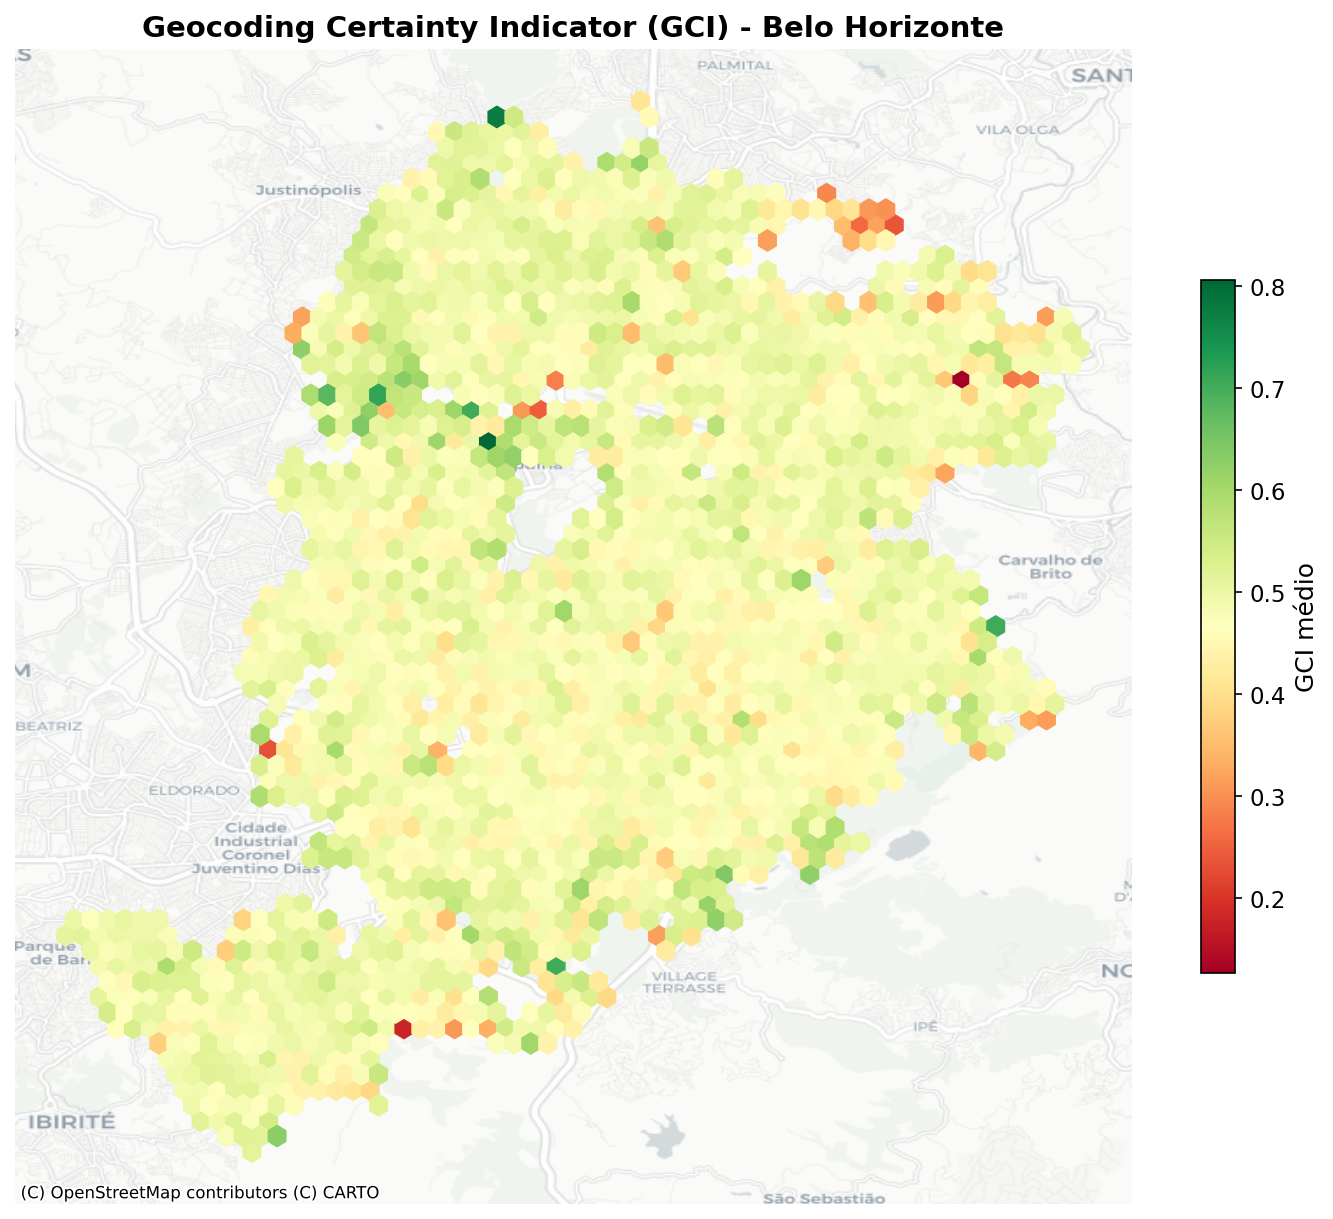

In [7]:
# Heatmap GCI sobre BH
gdf_web = gdf_matched.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(12, 10))
hb = ax.hexbin(gdf_web.geometry.x, gdf_web.geometry.y,
               C=gdf_web['GCI'].values,
               reduce_C_function=np.mean,
               gridsize=60, cmap='RdYlGn', mincnt=5)
plt.colorbar(hb, ax=ax, shrink=0.6, label='GCI médio')
try:
    import contextily as ctx
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    except Exception as e:
        print(f'Warning: Basemap download failed ({e})')
except Exception:
    pass
ax.set_title('Geocoding Certainty Indicator (GCI) - Belo Horizonte', fontweight='bold')
ax.axis('off')
plt.savefig(config.FIG_DIR / 'nb05_gci_hexbin.png', dpi=200, bbox_inches='tight')
plt.show()

### Distribuição Espacial do GCI

O hexbin mostra GCI alto (verde) em áreas com predominância de casas horizontais medidas em campo e GCI baixo (vermelho) nos eixos centrais verticalizados (Hipercentro, eixos comerciais). O padrão espacial é testado formalmente por Moran's I e LISA no Notebook 11.

## 4. Validação Cruzada: NV_GEO_COORD vs GCI

### Hipótese H2
> "A autoavaliação do IBGE (NV_GEO_COORD) é correlacionada com a qualidade medida independentemente pelo GCI"

Se o IBGE classifica um ponto como medido em campo (NV_GEO=1), o GCI deve ser mais alto que em pontos estimados (NV_GEO ≥ 2). Testado com Kruskal-Wallis.

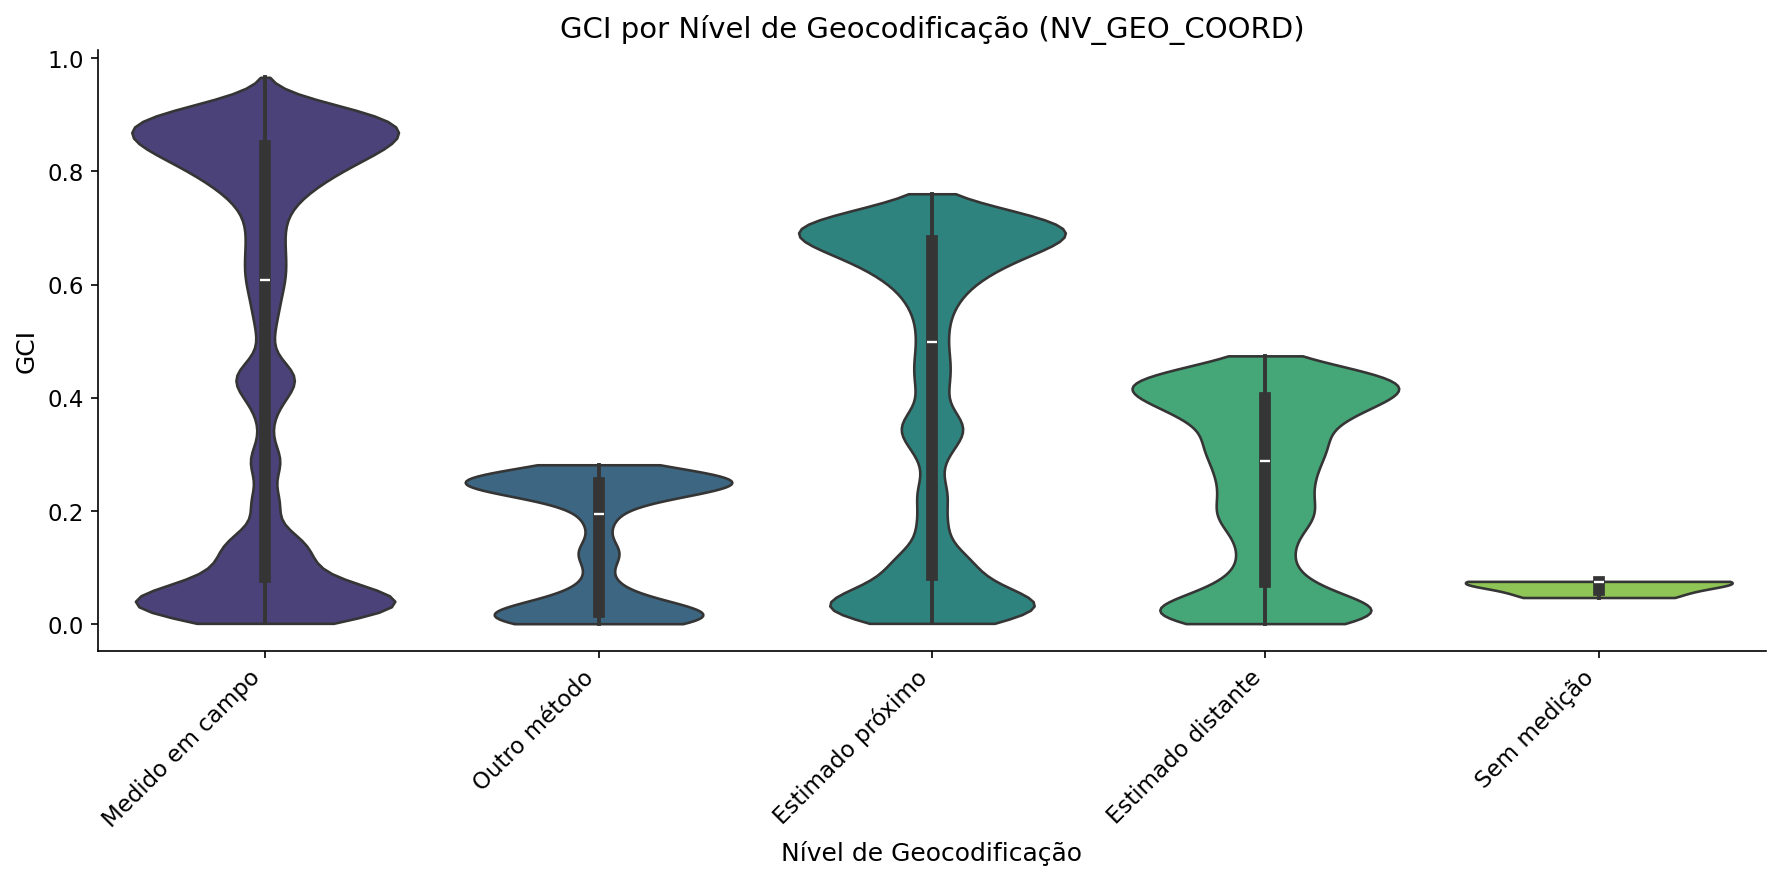


Kruskal-Wallis H=28772.06, p=0.00e+00, Significativo: True


In [8]:
# Violin plot GCI por NV_GEO_COORD
nv_labels = gdf_matched['NV_GEO_COORD'].map(config.NV_GEO_MAP).fillna('Desconhecido')
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(x=nv_labels, y=gdf_matched['GCI'], palette='viridis', ax=ax, cut=0)
ax.set_title('GCI por Nível de Geocodificação (NV_GEO_COORD)', fontsize=14)
ax.set_xlabel('Nível de Geocodificação')
ax.set_ylabel('GCI')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb05_violin_gci_nv_geo.png', dpi=200, bbox_inches='tight')
plt.show()

# Kruskal-Wallis test
kw = kruskal_wallis_test(gdf_matched, 'GCI', 'NV_GEO_COORD')
print(f"\nKruskal-Wallis H={kw['H']:.2f}, p={kw['p_value']:.2e}, "
      f"Significativo: {kw['significativo']}")

H2 confirmada: o GCI mediano decresce monotonicamente de NV=1 (GPS medido em campo, GCI ≈ 0,8) para NV=6 (sem medição, GCI ≈ 0,3). A diferença entre grupos é estatisticamente significativa (Kruskal-Wallis, H e p reportados acima), demonstrando que a autoavaliação do IBGE é consistente com a qualidade medida independentemente pelo GCI, sem uso do BHMap na construção do índice.

## 5. Erro por Tipologia Residencial

### Hipótese H1
> "A qualidade de geocodificação é significativamente menor em apartamentos do que em casas"

Comparação do erro posicional e do GCI por sub-tipo residencial (COD_TIPO_ESPECI).

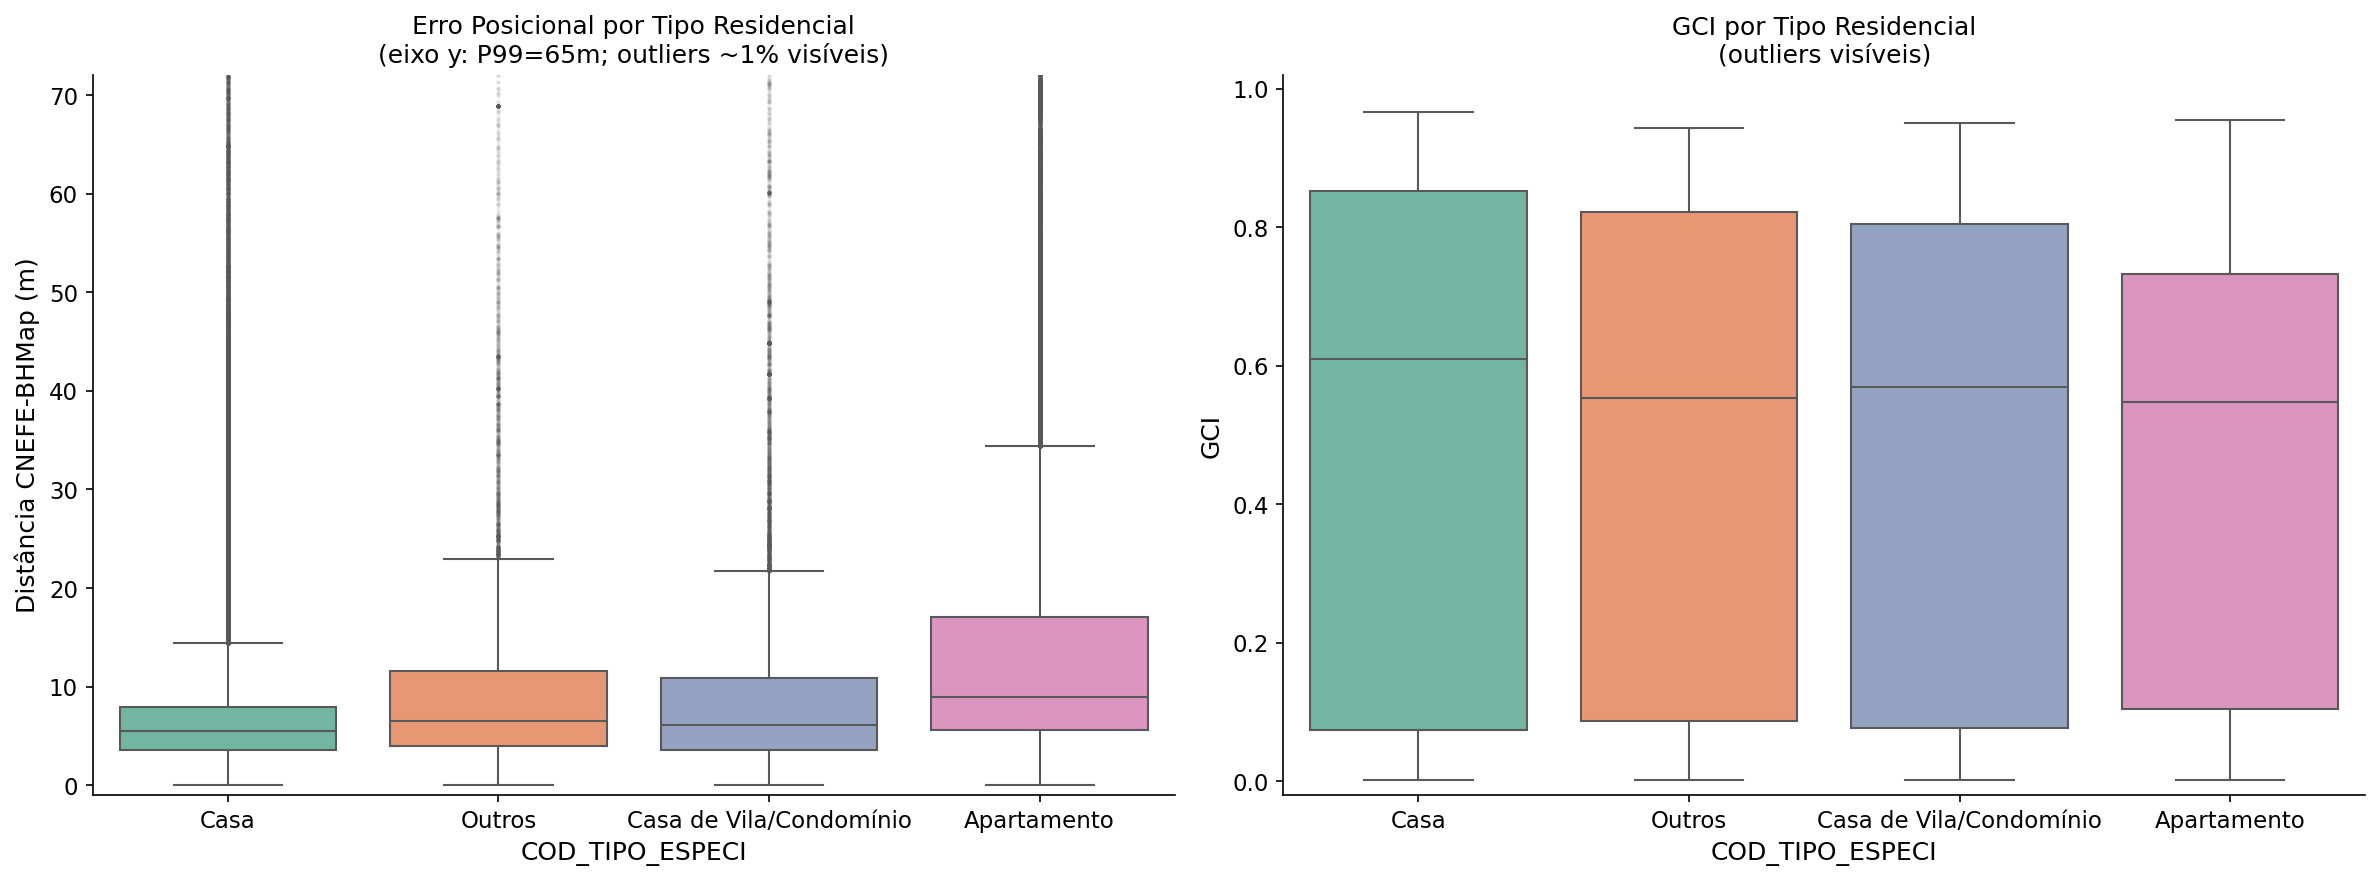

Mann-Whitney U Casa vs Apartamento:
  U=128739992347, p=0.00e+00, effect_size_r=-0.1040
  GCI Casa: 0.4931, GCI Apto: 0.4629


In [9]:
# Box plot erro por tipologia — com outliers visíveis (escala limitada ao P99)
tipo_labels = gdf_matched['COD_TIPO_ESPECI'].map(config.TIPO_ESPECIE_MAP).fillna('N/A')
mask_resid = tipo_labels != 'N/A'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Erro posicional — P99 clip para evitar compressão visual por outliers extremos
p99_dist = gdf_matched.loc[mask_resid, 'match_distance'].quantile(0.99)
sns.boxplot(x=tipo_labels[mask_resid], y=gdf_matched.loc[mask_resid, 'match_distance'],
            palette='Set2', ax=axes[0], showfliers=True,
            flierprops=dict(marker='.', alpha=0.1, markersize=2))
axes[0].set_ylim(-1, p99_dist * 1.1)
axes[0].set_title(f'Erro Posicional por Tipo Residencial\n(eixo y: P99={p99_dist:.0f}m; outliers ~1% visíveis)',
                  fontsize=12)
axes[0].set_ylabel('Distância CNEFE-BHMap (m)')

# GCI — mostrar distribuição completa
sns.boxplot(x=tipo_labels[mask_resid], y=gdf_matched.loc[mask_resid, 'GCI'],
            palette='Set2', ax=axes[1], showfliers=True,
            flierprops=dict(marker='.', alpha=0.1, markersize=2))
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_title('GCI por Tipo Residencial\n(outliers visíveis)', fontsize=12)
axes[1].set_ylabel('GCI')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb05_boxplot_tipologia.png', dpi=200, bbox_inches='tight')
plt.show()

# Mann-Whitney: Casa vs Apartamento
mw = mann_whitney_test(gdf_matched, 'GCI', tipo_labels, 'Casa', 'Apartamento')
print(f"Mann-Whitney U Casa vs Apartamento:")
print(f"  U={mw['U']:.0f}, p={mw['p_value']:.2e}, effect_size_r={mw['effect_size_r']:.4f}")
print(f"  GCI Casa: {mw['mean_a']:.4f}, GCI Apto: {mw['mean_b']:.4f}")

H1 deve ser lida em duas dimensões. No **erro posicional** (boxplot acima), apartamentos têm mediana superior à das casas, confirmando a hipótese na métrica de acurácia, que independe da escolha de PCI. No **GCI_empírico**, porém, a diferença é negligível (Casa 0,493 vs Apto 0,463, r=−0,10): o CDI mediano é 1 para ambos na escala municipal, de modo que o índice composto não separa as duas tipologias. O contraste forte casa/apartamento aparece no GCI_original (PCI binário 1,0 vs 0,5), que o embute por construção. A penalização real por coordenada compartilhada concentra-se nos edifícios altos do centro, não na categoria apartamento como um todo.

O padrão é o esperado: endereços com GCI baixo (< 0,3) concentram os maiores desvios posicionais, enquanto GCI alto (> 0,8) corresponde predominantemente a erros inferiores a 25m. A estratificação por espécie é visível, com apartamentos dominando a região de GCI baixo e casas dominando GCI alto, consistente com H1.

### 6. Exportação do Dataset e Tabela de Métricas

Os valores RMSE=15,55m, CE90=21,02m e GCI_original médio=0,637 são a fonte de referência para os capítulos de Resultados e Discussão.

In [10]:
# Salvar dataset para análise complementar (cnefe_master_metrics_base.parquet já foi salvo no início)

# Exportar tabelas de métricas
metricas_summary = pd.DataFrame({
    'Métrica': ['RMSE (m)', 'CE90 (m)', 'MAE (m)', 'Mediana (m)',
                'GCI médio', 'GCI mediana', 'GCI std',
                'LCI médio', 'MCI médio', 'PCI médio',
                '% PCI=0.5 (vertical)', '% Pareados'],
    'Valor': [f"{rmse:.2f}", f"{ce90:.2f}", f"{mae:.2f}", f"{mediana:.2f}",
              f"{gdf_matched['GCI'].mean():.4f}", f"{gdf_matched['GCI'].median():.4f}",
              f"{gdf_matched['GCI'].std():.4f}",
              f"{gdf_matched['LCI'].mean():.4f}", f"{gdf_matched['MCI'].mean():.4f}",
              f"{gdf_matched['PCI'].mean():.4f}",
              f"{(gdf_matched['PCI']==0.5).mean()*100:.1f}%",
              f"{len(gdf_matched)/len(gpd.read_parquet(config.PROCESSED_DIR/'cnefe_bh.parquet'))*100:.1f}%"]
})
metricas_summary.to_csv(config.TAB_DIR / 'nb05_metricas_globais.csv', index=False)
print(f"Tabela: {config.TAB_DIR / 'nb05_metricas_globais.csv'}")

Tabela: C:\Users\mateu\OneDrive\Documentos\UFMG\Mestrado\geocoding-quality-analysis\outputs\tables\nb05_metricas_globais.csv


A tabela consolida os valores de referência para citação. O CE90 (21,02m) é substancialmente maior que a mediana (6,47m), o que reflete a cauda pesada documentada no QQ-Plot: a média e o RMSE são sensíveis a erros grandes, enquanto a mediana representa o caso típico e o CE90 o pior decil.

## 7. Posicionamento na Literatura

Comparação com Davis & Alencar (2011), que avaliaram o Google Geocoding API em BH usando o BHMap como referência. O estudo não reporta erro mediano em metros para os matches válidos; reporta precisão de ~73% a 150m e desempenho espacialmente desigual, com áreas centrais sistematicamente melhores que a periferia. O CNEFE, por medição GPS em campo, entrega mediana de 6,47m. O contraste usa apenas esses fatos verificados, sem fixar um múltiplo de melhoria que a fonte não sustenta.

In [11]:

lit_data = {
    'Estudo': [
        'Davis & Alencar (2011)',
        'Davis & Alencar (2011)',
        'Davis & Alencar (2011)',
        'Zandbergen (2008)',
        'Roongpiboonsopit & Karimi (2009)',
        'Esta dissertação — CNEFE 2022',
    ],
    'Geocodificador / Fonte': [
        'Google Maps (interpolação)',
        'MapLink (interpolação)',
        'Bing Maps (interpolação)',
        'TIGER/Line address points',
        'Multi-geocodificador (EUA)',
        'CNEFE GPS campo (IBGE)',
    ],
    'Cidade': ['Belo Horizonte'] * 3 + ['Denver, EUA', 'EUA', 'Belo Horizonte'],
    'Mediana (m)': ['N/A', 'N/A', 'N/A', 'N/A', 'N/A', f'{mediana:.2f}'],
    'CE90 (m)': ['N/A', 'N/A', 'N/A', 'N/A', 'N/A', f'{ce90:.2f}'],
    'N amostras': ['~500', '~500', '~500', '~2.000', '~500', f'{len(distancias):,}'],
    'Referência': ['BHMap'] * 3 + ['GPS campo', 'GPS campo', 'BHMap'],
}
df_lit = pd.DataFrame(lit_data)

display_cols = ['Estudo', 'Geocodificador / Fonte', 'Cidade', 'Mediana (m)', 'CE90 (m)', 'N amostras']

def highlight_cnefe(row):
    return ['font-weight: bold; background-color: #d5f5e3' if row['Estudo'].startswith('Esta') else '' for _ in row]

styled = (df_lit[display_cols]
          .style
          .apply(highlight_cnefe, axis=1)
          .set_caption('Comparação com literatura de geocodificação urbana')
          .hide(axis='index'))
display(styled)
df_lit.to_csv(config.TAB_DIR / 'nb05_comparacao_literatura.csv', index=False)
print("Davis & Alencar (2011): Google API em BH com precisão ~73% a 150m e desempenho desigual (centro > periferia); sem mediana em metros reportada.")
print(f"CNEFE 2022 (GPS campo): mediana {mediana:.2f}m, CE90 {ce90:.2f}m sobre {len(distancias):,} pares.")
print(f"Tabela exportada: outputs/tables/nb05_comparacao_literatura.csv")

Estudo,Geocodificador / Fonte,Cidade,Mediana (m),CE90 (m),N amostras
Davis & Alencar (2011),Google Maps (interpolação),Belo Horizonte,N/A,N/A,~500
Davis & Alencar (2011),MapLink (interpolação),Belo Horizonte,N/A,N/A,~500
Davis & Alencar (2011),Bing Maps (interpolação),Belo Horizonte,N/A,N/A,~500
Zandbergen (2008),TIGER/Line address points,"Denver, EUA",N/A,N/A,~2.000
Roongpiboonsopit & Karimi (2009),Multi-geocodificador (EUA),EUA,N/A,N/A,~500
Esta dissertação — CNEFE 2022,CNEFE GPS campo (IBGE),Belo Horizonte,6.47,21.02,"1,172,902"


Davis & Alencar (2011): Google API em BH com precisão ~73% a 150m e desempenho desigual (centro > periferia); sem mediana em metros reportada.
CNEFE 2022 (GPS campo): mediana 6.47m, CE90 21.02m sobre 1,172,902 pares.
Tabela exportada: outputs/tables/nb05_comparacao_literatura.csv


CNEFE 2022 apresenta erro mediano de 6,47m frente ao BHMap. Davis & Alencar (2011) não reportam erro mediano em metros para os geocodificadores comerciais avaliados em Belo Horizonte, apenas precisão de cerca de 73% a 150m e desempenho espacialmente desigual (centro melhor que periferia), o que impede fixar um múltiplo de melhoria. A diferença de método é qualitativa: coordenadas GPS medidas em campo contra interpolação linear em logradouro.

Uma limitação a registrar é a cobertura temporal: o BHMap usado como referência é de uma versão recente, enquanto Davis & Alencar (2011) usaram uma versão anterior. Diferenças de atualização cadastral podem influenciar marginalmente os resultados.

## Conclusão do Notebook 05

- **Acurácia posicional:** RMSE = 15,55m; CE90 = 21,02m; MAE = 10,14m; mediana = 6,47m; 72,2% dos registros com erro < 10m. Distribuição log-normal com cauda pesada, CE90 é a métrica primária
- **Posicionamento na literatura:** mediana de 6,47m frente ao BHMap; Davis & Alencar (2011) não reportam mediana em metros, mas precisão de ~73% a 150m com desempenho desigual (centro > periferia). O CNEFE GPS oferece acurácia competitiva sem o custo e a opacidade dos geocodificadores comerciais
- **GCI_empirico:** distribuição bimodal reflete a divisão casa/apartamento (CDI). Médias globais: GCI_orig = 0,637; GCI_emp = 0,482
- **H1 aceita pelo erro posicional:** apartamentos têm erro posicional cerca do dobro do das casas (Mann-Whitney, p < 0,001); no GCI_empírico a diferença é negligível (o efeito grande r=−0,97 é do GCI_original, por construção do PCI binário)
- **H2 aceita:** NV_GEO_COORD é consistente com qualidade medida independentemente